# 11 · NYC L1C inputs and fixed-model inference

Apply Notebook 08's epoch-18 RGB and RGB+NIR models to **13 site–date windows at 10 NYC sites**, using Sentinel-2 L1C imagery from 21 September and 18 October 2024.

The cloud inference was completed and its returned outputs are used in Notebook 12 and the Summary. This local notebook contains saved input previews and the complete inference code; rerunning inference requires the cloud checkpoints.

Inputs are standardized 512 × 512 images. Outputs are water probabilities and masks on the central 128 × 128, 10 m grid. Sources: [public Sentinel-2 archive](https://docs.cloud.google.com/storage/docs/public-datasets) · [product conventions](https://sentiwiki.copernicus.eu/web/s2-products).

## Completed NYC inference: all 13 returned comparisons

These images are the saved outputs returned from the cloud inference run. The display cell loads the existing comparisons; it does not run model inference. All 13 site–date windows are retained.

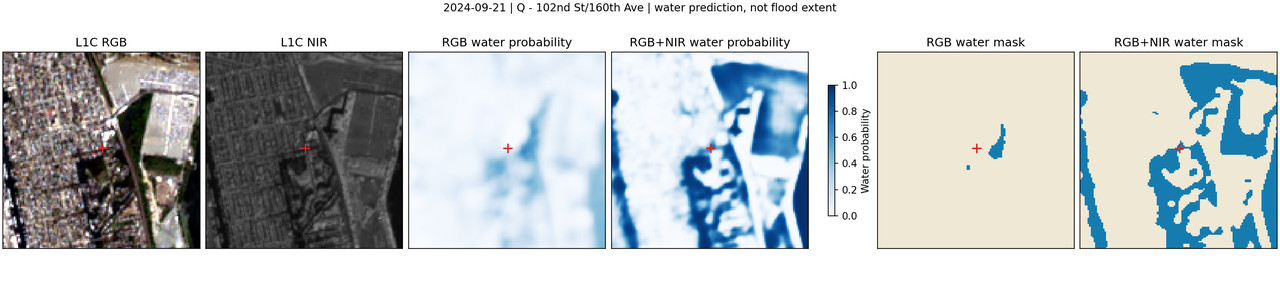

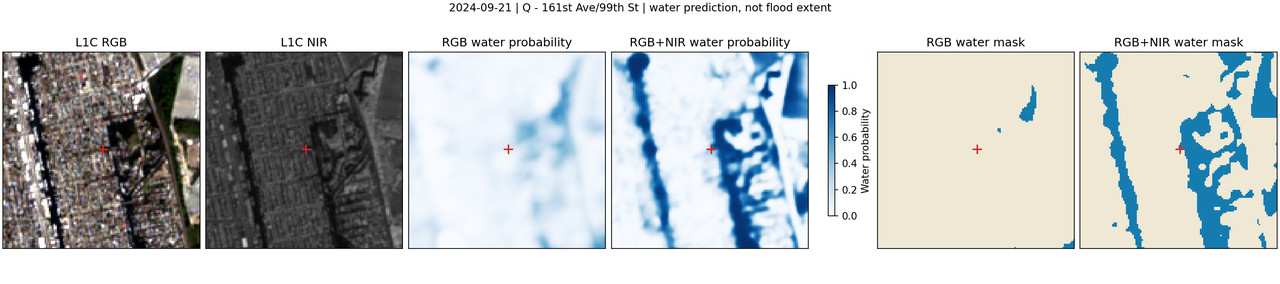

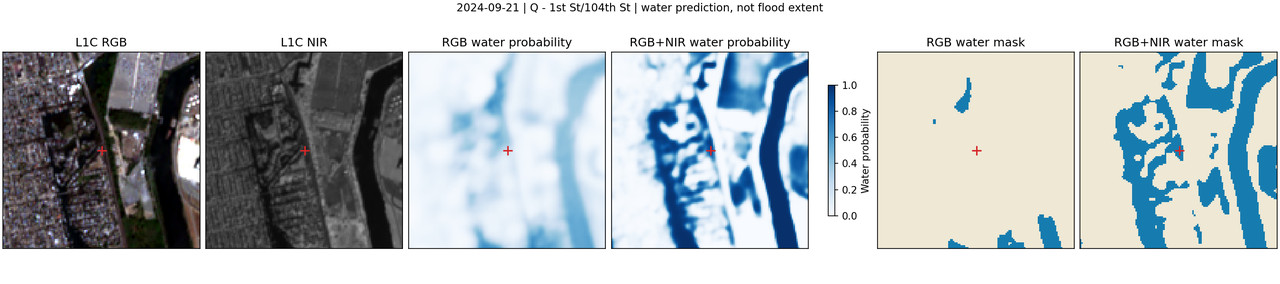

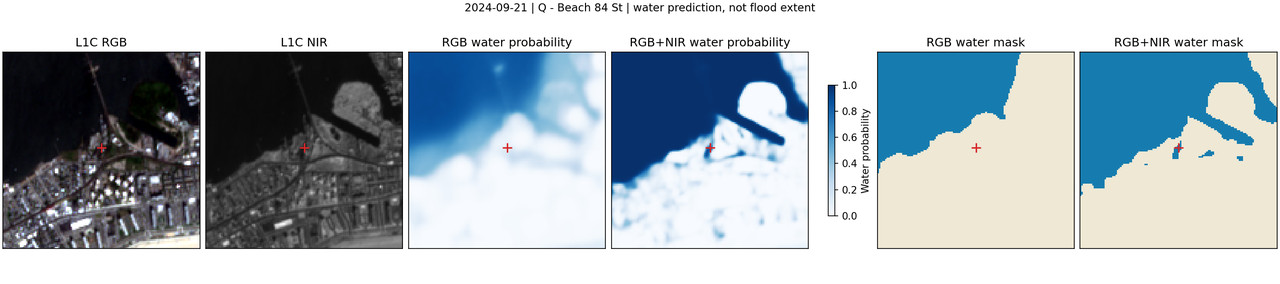

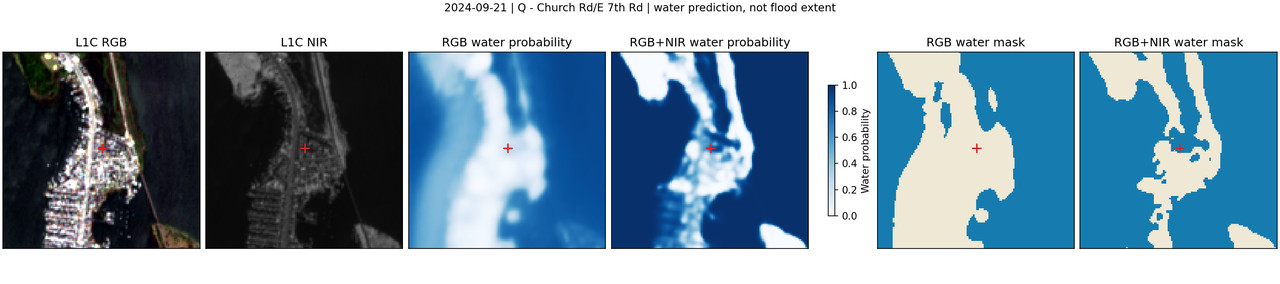

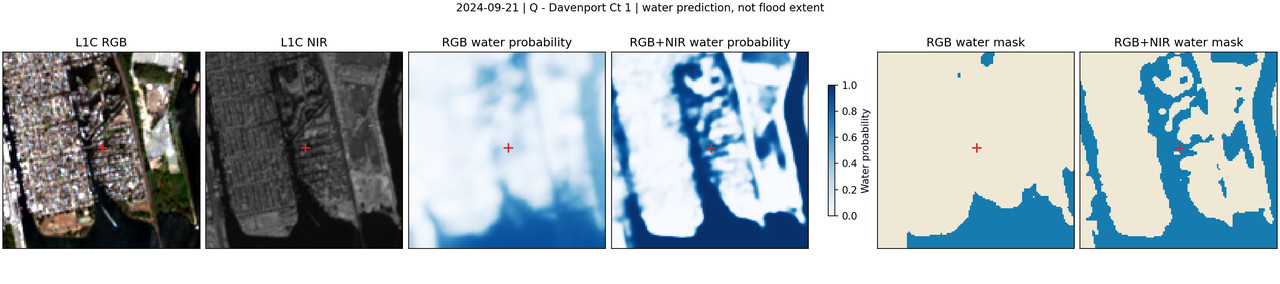

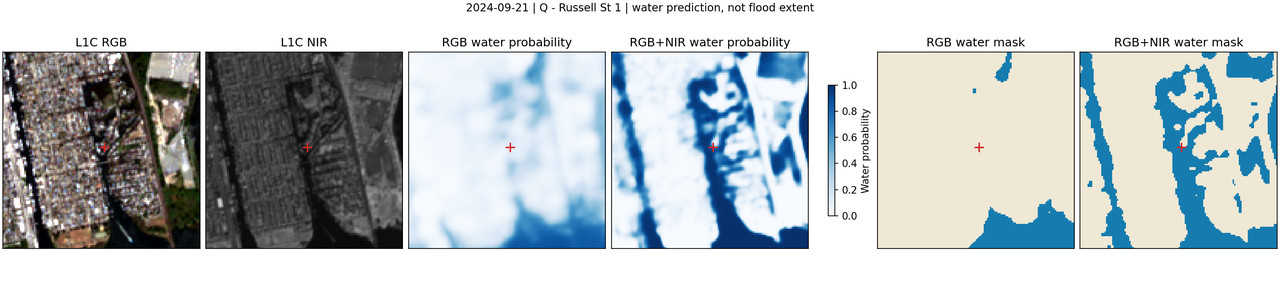

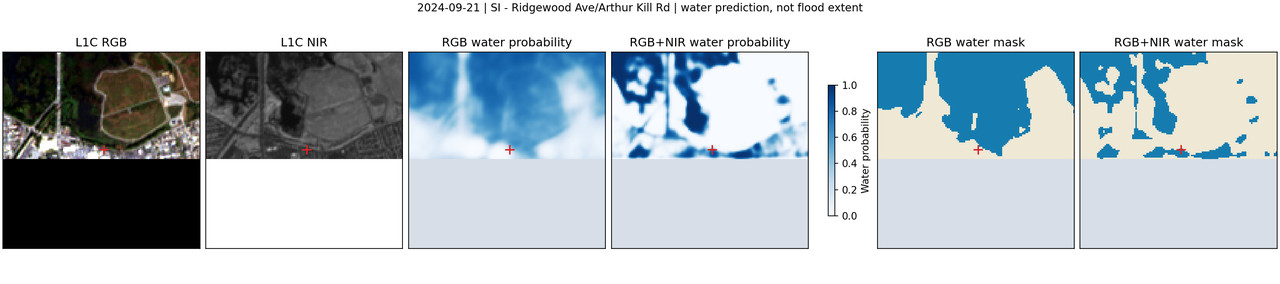

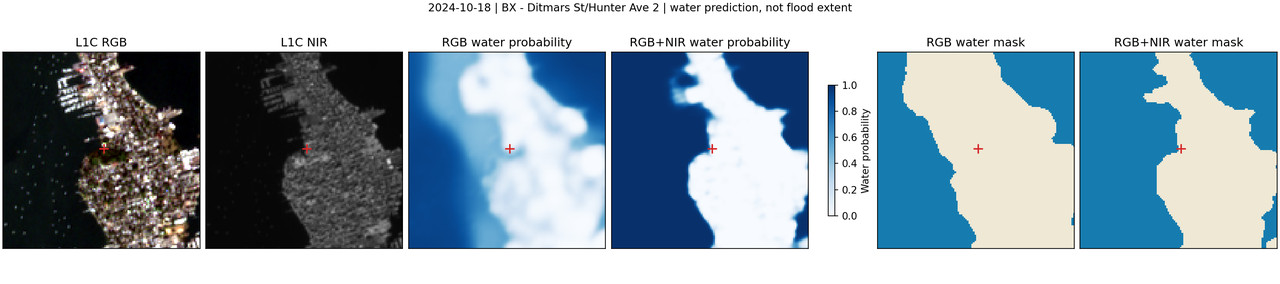

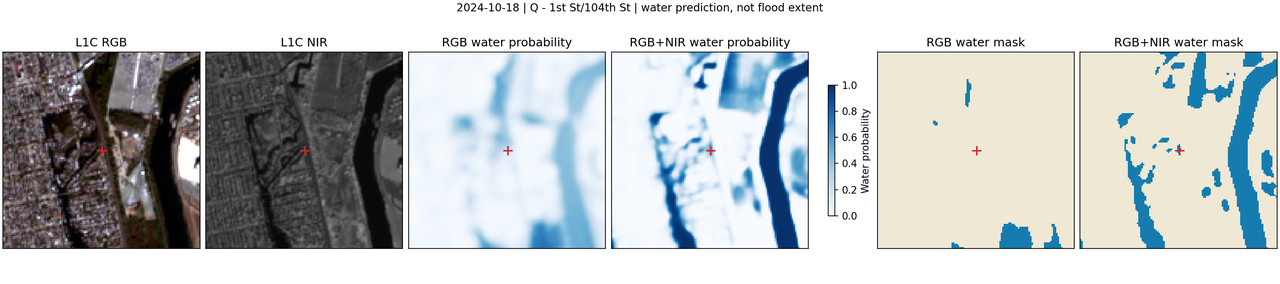

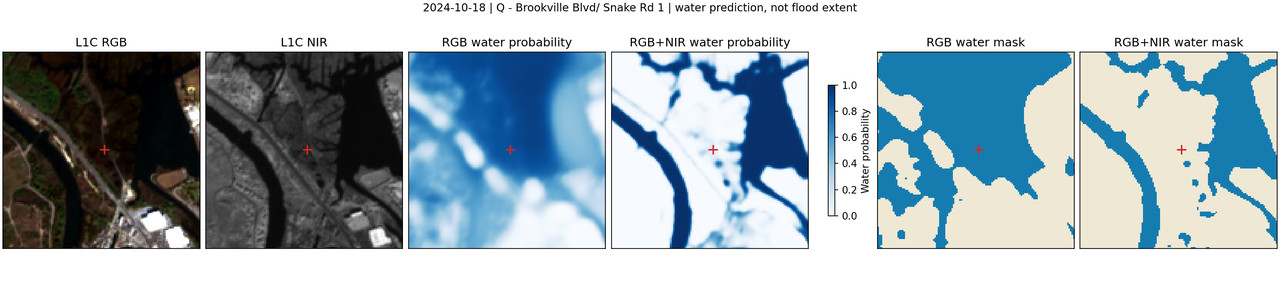

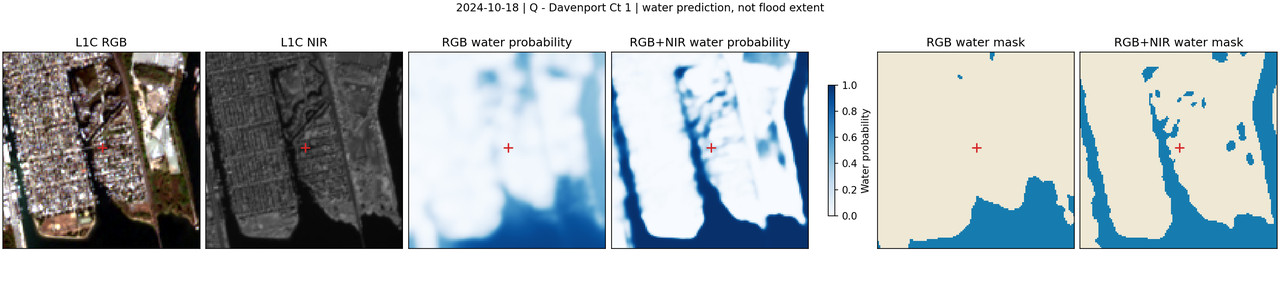

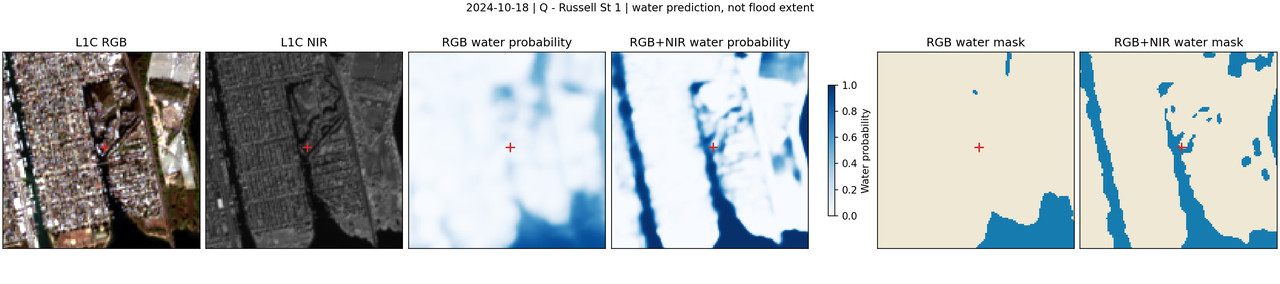

Displayed site-date comparisons: 13


In [1]:
from pathlib import Path
import csv
from IPython.display import display, Image, Markdown
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

recorded_images = sorted((ROOT/'figure_sources/nyc_inference').glob('*_comparison.png'))
for path in recorded_images:
    display(Image(filename=str(path)))
print('Displayed site-date comparisons:', len(recorded_images))


## 1. Inputs and fixed preprocessing

Use the existing `data/nyc/l1c_chips/` files and Notebook 08 checkpoints.

| Setting | Value |
|---|---|
| Band order | B4/B3/B2, with B8 added for RGB+NIR |
| Reflectance | Product metadata: (DN − 1000)/10000 for these products |
| Invalid input | DN 0, 65535 and non-finite values; shared four-band mask |
| Standardization | Training mean/std saved in each checkpoint |
| Context / output | 512 × 512 input; central 128 × 128 at 10 m |
| Decision | Original argmax rule; no threshold tuning |
| Quality | Co-temporal SCL, nearest-neighbor alignment; retain classes 2/4/5/6/7 |
| Export | float32 probabilities, int16 masks, nodata=-1; original center georeferencing |

SCL supplies quality screening, not flood labels. Overlapping windows are analyzed separately.

In [1]:
from pathlib import Path
from datetime import datetime
import json,csv
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.warp import reproject,Resampling,transform
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,BoundaryNorm
from IPython.display import display,Markdown
ROOT=Path.cwd() if (Path.cwd()/"data").exists() else Path.cwd().parent
DATA=ROOT/"data/nyc/l1c_chips"
records=json.loads((DATA/"chips.json").read_text(encoding="utf-8"))["records"]
PREVIEW=ROOT/"outputs/nyc_l1c_preview";PREVIEW.mkdir(parents=True,exist_ok=True)
BANDS=["B4","B3","B2","B8"]
EXPERIMENTS={"rgb":BANDS[:3],"rgb_nir":BANDS}
def table(rows,cols):
    def fmt(v):return f"{v:.4f}" if isinstance(v,(float,np.floating)) else str(v)
    display(Markdown("\n".join(["|"+"|".join(cols)+"|","|"+"---|"*len(cols)]+
        ["|"+"|".join(fmt(r[c]) for c in cols)+"|" for r in rows])))
def save_csv(path,rows):
    with path.open("w",newline="",encoding="utf-8-sig") as f:
        w=csv.DictWriter(f,fieldnames=list(rows[0]));w.writeheader();w.writerows(rows)
def read_chip(rec):
    with rasterio.open(ROOT/rec["dn_path"]) as src:
        assert list(src.descriptions)==BANDS
        dn=src.read().astype("float32");profile=src.profile.copy()
        col,row,width,height=rec["central_window"]
        center=Window(col,row,width,height)
        central_transform=src.window_transform(center)
    keep=((dn!=0)&(dn!=65535)&np.isfinite(dn)).all(axis=0)
    offsets=np.array(rec["radio_add_offset"],dtype="float32")[:,None,None]
    reflectance=(dn+offsets)/float(rec["quantification"])
    reflectance[:,~keep]=np.nan
    sl=(slice(row,row+height),slice(col,col+width))
    central_profile={**profile,"width":width,"height":height,"transform":central_transform}
    scl=np.zeros((height,width),dtype="uint8")
    with rasterio.open(ROOT/rec["scl_path"]) as src:
        reproject(src.read(1),scl,src_transform=src.transform,src_crs=src.crs,
                  dst_transform=central_transform,dst_crs=profile["crs"],resampling=Resampling.nearest)
    clear=keep[sl]&np.isin(scl,[2,4,5,6,7])
    xx,yy=transform("EPSG:4326",profile["crs"],[float(rec["site"]["longitude"])],[float(rec["site"]["latitude"])])
    px,py=(~central_transform)*(xx[0],yy[0])
    return reflectance,keep,sl,clear,central_profile,(px,py),scl

def rgb_display(image):
    rgb=np.moveaxis(image[:3],0,-1);finite=np.isfinite(rgb).all(axis=-1)
    if finite.any():
        lo,hi=np.percentile(rgb[finite],[2,98],axis=0)
        rgb=np.clip((rgb-lo)/np.maximum(hi-lo,1e-6),0,1)
    return np.nan_to_num(rgb)
print("Downloaded L1C site-date windows:",len(records))

Downloaded L1C site-date windows: 13


## 2. Input completeness and reflectance

Summarize the 13 downloaded windows using the raw DN and product metadata. Preserve valid negative reflectance values; display stretching is not model preprocessing.

The SI Ridgewood center is about 54.7% usable; the other centers are complete. Some surrounding context also has missing data, which remains explicitly masked.

In [2]:
audit=[]
for rec in records:
    x,keep,sl,clear,profile,point,scl=read_chip(rec)
    center=x[:,sl[0],sl[1]]
    audit.append(dict(date=rec["date"],sensor=rec["site"]["sensor_name"],
        context_valid=float(keep.mean()),center_valid=float(keep[sl].mean()),usable_fraction=float(clear.mean()),
        red_median=float(np.nanmedian(center[0])),nir_median=float(np.nanmedian(center[3])),
        offset=rec["radio_add_offset"][0],quantification=rec["quantification"]))
table(audit,["date","sensor","context_valid","center_valid","usable_fraction","red_median","nir_median"])
save_csv(PREVIEW/"input_statistics.csv",audit)

|date|sensor|context_valid|center_valid|usable_fraction|red_median|nir_median|
|---|---|---|---|---|---|---|
|2024-09-21|Q - Beach 84 St|0.7493|1.0000|1.0000|0.0810|0.1266|
|2024-09-21|Q - Davenport Ct 1|1.0000|1.0000|1.0000|0.0861|0.1358|
|2024-09-21|Q - Russell St 1|1.0000|1.0000|1.0000|0.0965|0.1420|
|2024-09-21|Q - 102nd St/160th Ave|1.0000|1.0000|1.0000|0.1064|0.1442|
|2024-09-21|Q - 1st St/104th St|1.0000|1.0000|1.0000|0.0989|0.1448|
|2024-09-21|Q - 161st Ave/99th St|1.0000|1.0000|1.0000|0.1039|0.1420|
|2024-09-21|SI - Ridgewood Ave/Arthur Kill Rd|0.5117|0.5469|0.5469|0.0713|0.1615|
|2024-09-21|Q - Church Rd/E 7th Rd|0.9623|1.0000|1.0000|0.0489|0.0320|
|2024-10-18|Q - Russell St 1|1.0000|1.0000|1.0000|0.1010|0.1467|
|2024-10-18|Q - Brookville Blvd/ Snake Rd 1|1.0000|1.0000|1.0000|0.0566|0.1279|
|2024-10-18|Q - Davenport Ct 1|1.0000|1.0000|1.0000|0.0922|0.1425|
|2024-10-18|Q - 1st St/104th St|1.0000|1.0000|1.0000|0.1026|0.1473|
|2024-10-18|BX - Ditmars St/Hunter Ave 2|1.0000|1.0000|1.0000|0.0424|0.0240|

## 3. Input previews

Display the first configured site on each date. The red cross locates the FloodNet sensor. These panels show the inputs; the final inference gallery includes all 13 windows.

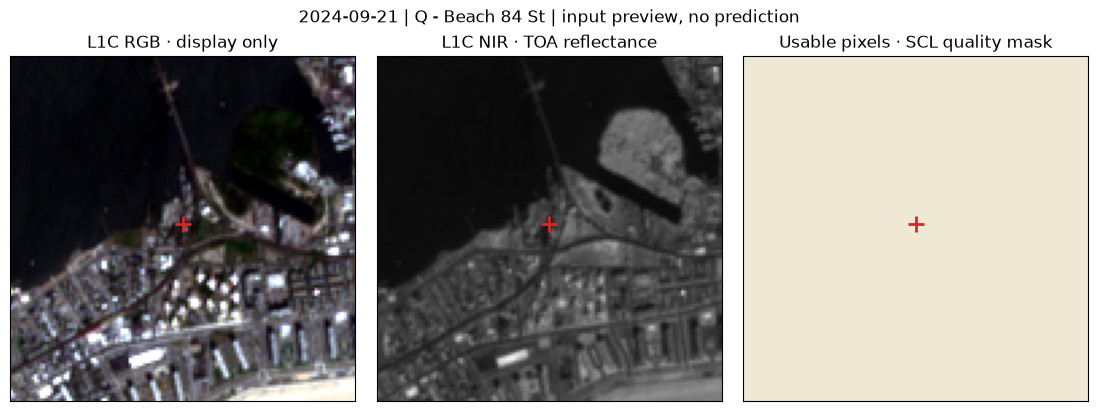

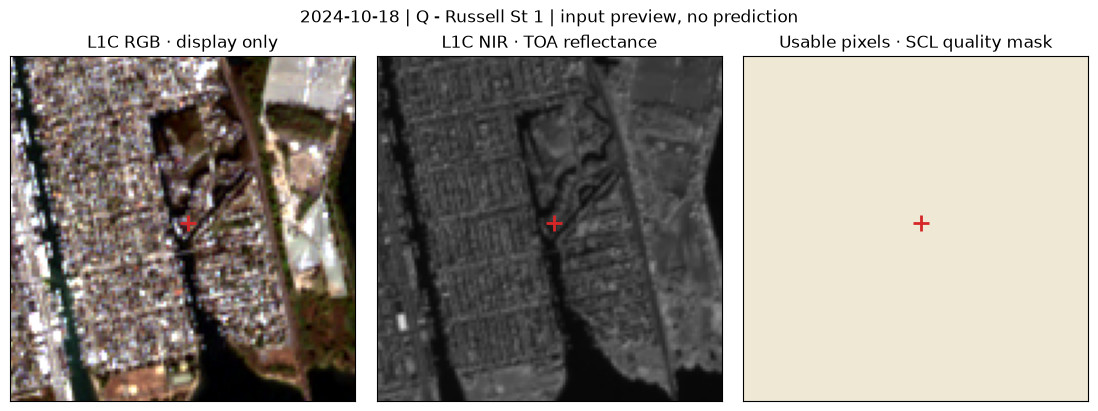

In [3]:
for date in sorted({r["date"] for r in records}):
    rec=next(r for r in records if r["date"]==date)
    x,keep,sl,clear,profile,(px,py),scl=read_chip(rec)
    center=x[:,sl[0],sl[1]]
    fig,axes=plt.subplots(1,3,figsize=(11,4),layout="constrained")
    axes[0].imshow(rgb_display(center));axes[0].set_title("L1C RGB · display only")
    axes[1].imshow(center[3],cmap="gray",vmin=0,vmax=.6);axes[1].set_title("L1C NIR · TOA reflectance")
    axes[2].imshow(clear,cmap=ListedColormap(["#d7dee7","#eee8d5"]),vmin=0,vmax=1,interpolation="nearest")
    axes[2].set_title("Usable pixels · SCL quality mask")
    for ax in axes:
        ax.plot(px-.5,py-.5,"+",color="#d62728",markersize=11,markeredgewidth=2)
        ax.set_xticks([]);ax.set_yticks([])
    fig.suptitle(f"{date} | {rec['site']['sensor_name']} | input preview, no prediction")
    fig.savefig(PREVIEW/f"{date}_l1c_preview.png",dpi=150);plt.show();plt.close(fig)

## 4. Load the fixed models

Select the completed `worldfloods_unet_*` run with `RUN_NAME`. An empty value chooses the latest directory containing both checkpoints. Check the printed path and saved epochs; the reported experiment uses epoch 18 for both models.

Reconstruct the U-Net independently of the training notebook, reuse checkpoint standardization and create a timestamped `nyc_l1c_*` output directory.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
RUN_NAME=""  # Select the completed worldfloods_unet_... directory if several runs exist.
candidates=sorted(p for p in (ROOT/"runs").glob("worldfloods_unet_*")
                  if all((p/name/"best.pt").exists() for name in EXPERIMENTS))
RUN=ROOT/"runs"/RUN_NAME if RUN_NAME else candidates[-1]
OUT=RUN/datetime.now().strftime("nyc_l1c_%Y%m%d_%H%M%S_%f");OUT.mkdir(parents=True)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark=False;torch.backends.cudnn.deterministic=True
print("Run:",RUN,"\nOutputs:",OUT,"\nDevice:",device)
import torch
from torch import nn

class DoubleConv(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        self.encoders = nn.ModuleList([
            DoubleConv(in_channels, 64), DoubleConv(64, 128),
            DoubleConv(128, 256), DoubleConv(256, 512),
        ])
        self.pool = nn.MaxPool2d(2)
        self.decoders = nn.ModuleList([
            DoubleConv(512 + 256, 256), DoubleConv(256 + 128, 128),
            DoubleConv(128 + 64, 64),
        ])
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        skips = []
        for i, encoder in enumerate(self.encoders):
            if i:
                x = self.pool(x)
            x = encoder(x)
            skips.append(x)
        for decoder, skip in zip(self.decoders, reversed(skips[:-1])):
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=True)
            x = decoder(torch.cat([x, skip], dim=1))
        return self.head(x)





models={};settings={};provenance={}
for name,bands in EXPERIMENTS.items():
    ck=torch.load(RUN/name/"best.pt",map_location="cpu",weights_only=True)
    assert ck["bands"]==bands
    assert ck["config"]["architecture"]=="worldfloods_v1_unet_64_128_256_512_bilinear"
    model=UNet(len(bands),2).to(device);model.load_state_dict(ck["model"]);model.eval()
    models[name]=model;settings[name]=ck["config"]
    provenance[name]=dict(checkpoint=str(RUN/name/"best.pt"),epoch=ck["epoch"],bands=bands,training_config=ck["config"])
    print(name,"best epoch:",ck["epoch"],"bands:",bands)
    del ck
(OUT/"inference_config.json").write_text(json.dumps(dict(models=provenance,
    input="L1C (DN+product_offset)/quantification",input_size=512,central_size=128,
    scl_keep=[2,4,5,6,7],threshold="argmax",note="Water inference; no NYC pixel ground truth"),indent=2),encoding="utf-8")

## 5. Inference and GeoTIFF export

Run each model on the full context, crop the center and apply the shared usability mask. Save probabilities, binary water masks and the common valid region, plus station-pixel values.

These are model water probabilities, not water depths. Predicted water includes existing bays and channels; window areas are not added to estimate a citywide flood extent.

In [ ]:
summary=[];predictions={}
for index,rec in enumerate(records):
    x,keep,sl,clear,profile,(px,py),scl=read_chip(rec)
    site_id=rec["site"]["sensor_id"];stem=f"{rec['date']}_{site_id}"
    area_per_pixel=abs(profile["transform"].a*profile["transform"].e-profile["transform"].b*profile["transform"].d)
    for name,bands in EXPERIMENTS.items():
        cfg=settings[name]
        mean=np.array(cfg["channel_mean"],dtype="float32")[:,None,None]
        std=np.array(cfg["channel_std"],dtype="float32")[:,None,None]
        normalized=np.nan_to_num((x-mean)/std)[:len(bands)]
        use_amp=bool(cfg["amp"]) and device.type=="cuda"
        with torch.inference_mode(),torch.autocast(device_type=device.type,dtype=torch.float16,enabled=use_amp):
            logits=models[name](torch.from_numpy(normalized.copy())[None].to(device))
        probability=logits.float().softmax(1)[0,1].cpu().numpy()[sl].copy()
        mask=logits.argmax(1)[0].cpu().numpy()[sl].astype("int16")
        probability[~clear]=-1;mask[~clear]=-1
        predictions[index,name]=(probability,mask)
        for suffix,array,dtype in [("probability",probability,"float32"),("water_mask",mask,"int16")]:
            with rasterio.open(OUT/f"{stem}_{name}_{suffix}.tif","w",
                **{**profile,"count":1,"dtype":dtype,"nodata":-1,"compress":"deflate"}) as dst:
                dst.write(array,1)
                dst.update_tags(use="model water prediction, not flood extent ground truth",source_product=rec["product"],
                                checkpoint_epoch=str(provenance[name]["epoch"]))
        ri,ci=int(np.floor(py)),int(np.floor(px))
        usable=int(clear.sum());water=int((mask==1).sum())
        point_valid=bool(clear[ri,ci])
        summary.append(dict(date=rec["date"],utc=rec["utc"],sensor=rec["site"]["sensor_name"],
            sensor_id=site_id,experiment=name,best_epoch=provenance[name]["epoch"],
            valid_context_fraction=float(keep.mean()),usable_fraction=float(clear.mean()),
            usable_pixels=usable,predicted_water_pixels=water,
            predicted_water_fraction=water/usable if usable else float("nan"),
            predicted_water_area_m2=water*area_per_pixel,
            point_usable=point_valid,point_water_probability=float(probability[ri,ci]) if point_valid else float("nan"),
            point_prediction=int(mask[ri,ci]),point_scl=int(scl[ri,ci])))
    with rasterio.open(OUT/f"{stem}_usable.tif","w",
        **{**profile,"count":1,"dtype":"uint8","nodata":None,"compress":"deflate"}) as dst:
        dst.write(clear.astype("uint8"),1)
    print(index+1,"/",len(records),rec["date"],site_id,flush=True)
save_csv(OUT/"nyc_water_predictions.csv",summary)
table(summary,["date","sensor","experiment","predicted_water_fraction","point_usable","point_water_probability"])
print("Window water areas include bays and channels. Overlapping windows are reported separately.")

## 6. All-site comparison

Each row shows RGB, NIR, both water probabilities and both masks. Blue denotes water, beige non-water and grey excluded pixels. The red cross marks the sensor. Use a shared probability range of 0–1.

In [ ]:
mask_cmap=ListedColormap(["#d7dee7","#eee8d5","#167caf"])
mask_norm=BoundaryNorm([-1.5,-.5,.5,1.5],3)
prob_cmap=plt.get_cmap("Blues").copy();prob_cmap.set_bad("#d7dee7")
for index,rec in enumerate(records):
    x,keep,sl,clear,profile,(px,py),scl=read_chip(rec);center=x[:,sl[0],sl[1]]
    p3,m3=predictions[index,"rgb"];p4,m4=predictions[index,"rgb_nir"]
    fig,axes=plt.subplots(1,6,figsize=(18,4),layout="constrained")
    axes[0].imshow(rgb_display(center));axes[0].set_title("L1C RGB")
    axes[1].imshow(center[3],cmap="gray",vmin=0,vmax=.6);axes[1].set_title("L1C NIR")
    for ax,p,title in zip(axes[2:4],[p3,p4],["RGB water probability","RGB+NIR water probability"]):
        im=ax.imshow(np.ma.masked_less(p,0),cmap=prob_cmap,vmin=0,vmax=1);ax.set_title(title)
    fig.colorbar(im,ax=list(axes[2:4]),shrink=.5,label="Water probability")
    for ax,m,title in zip(axes[4:],[m3,m4],["RGB water mask","RGB+NIR water mask"]):
        ax.imshow(m,cmap=mask_cmap,norm=mask_norm,interpolation="nearest");ax.set_title(title)
    for ax in axes:
        ax.plot(px-.5,py-.5,"+",color="#d62728",markersize=10,markeredgewidth=1.5)
        ax.set_xticks([]);ax.set_yticks([])
    fig.suptitle(f"{rec['date']} | {rec['site']['sensor_name']} | water prediction, not flood extent",fontsize=11)
    fig.savefig(OUT/f"{rec['date']}_{rec['site']['sensor_id']}_comparison.png",dpi=150)
    plt.show();plt.close(fig)
print("Finished inference:",OUT)

## Outputs and next analysis

Save the executed notebook, station CSVs, probability/mask GeoTIFFs, usability masks, figures and inference configuration. Compare the returned predictions with co-temporal FloodNet measurements in [Notebook 12](12_nyc_floodnet_point_validation.ipynb).

Both dates have wet-site observations. They are separate application dates, not an assumed dry-before/flooded-after pair.